Training XGBoost Classifier...
--- XGBoost Classification Report ---
              precision    recall  f1-score   support

           0     0.9998    0.9920    0.9959     56864
           1     0.1584    0.8776    0.2683        98

    accuracy                         0.9918     56962
   macro avg     0.5791    0.9348    0.6321     56962
weighted avg     0.9983    0.9918    0.9946     56962



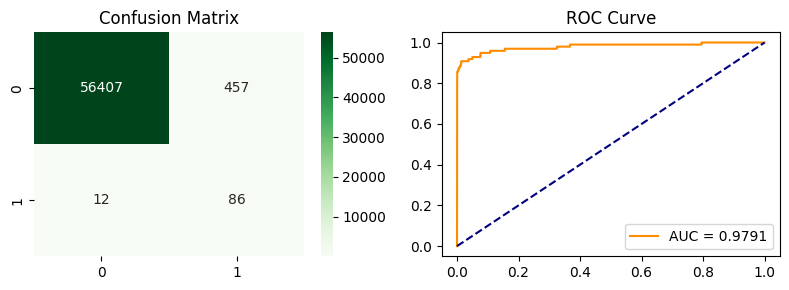

Day 3 completed successfully!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from imblearn.over_sampling import SMOTE

url = "https://raw.githubusercontent.com/nsethi31/Kaggle-Data-Credit-Card-Fraud-Detection/master/creditcard.csv"
df = pd.read_csv(url)

scaler = RobustScaler()
df['scaled_amount'] = scaler.fit_transform(df[['Amount']])
df['scaled_time'] = scaler.fit_transform(df[['Time']])
df = df.drop(columns=['Time', 'Amount'])

X = df.drop(columns=['Class'])
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Training XGBoost Classifier...")
xgb = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42, eval_metric='logloss')
xgb.fit(X_train_res, y_train_res)

y_pred = xgb.predict(X_test)
y_probs = xgb.predict_proba(X_test)[:, 1]

print("--- XGBoost Classification Report ---")
print(classification_report(y_test, y_pred, digits=4))

fig, ax = plt.subplots(1, 2, figsize=(8, 3))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens', ax=ax[0])
ax[0].set_title("Confusion Matrix")

fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)
ax[1].plot(fpr, tpr, color='darkorange', label=f'AUC = {roc_auc:.4f}')
ax[1].plot([0, 1], [0, 1], color='navy', linestyle='--')
ax[1].set_title("ROC Curve")
ax[1].legend()
plt.tight_layout()
plt.show()

joblib.dump(xgb, 'xgb_fraud_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Day 3 completed successfully!")
